In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## Langkah 1: Inspeksi Visual

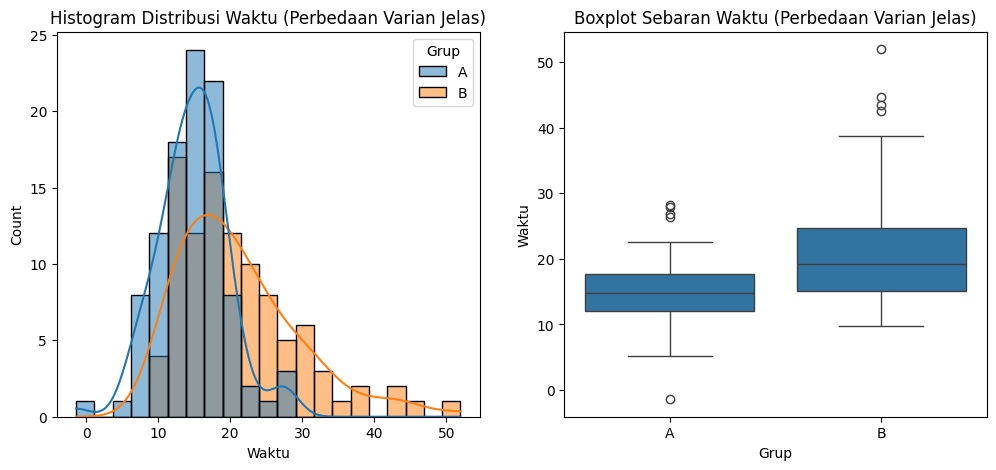

In [15]:
# Grup A: Tetap sama
grup_a = np.random.normal(loc=15, scale=5, size=100) 

# Grup B: Standar deviasi (scale) diperbesar dari 7 menjadi 12
# Ini akan menciptakan varians yang jauh lebih besar (144 vs 25)
grup_b = stats.skewnorm.rvs(a=4, loc=12, scale=12, size=100)

# --------------------------

df = pd.DataFrame({'Grup': ['A']*100 + ['B']*100,
                   'Waktu': np.concatenate([grup_a, grup_b])})

# Plotting untuk verifikasi visual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df, x='Waktu', hue='Grup', kde=True, ax=axes[0])
axes[0].set_title('Histogram Distribusi Waktu (Perbedaan Varian Jelas)')
sns.boxplot(df, x='Grup', y='Waktu', ax=axes[1])
axes[1].set_title('Boxplot Sebaran Waktu (Perbedaan Varian Jelas)')
plt.show()

## Langkah 2: Uji Statistik Formal

In [16]:
# Uji Statistik Formal
shapiro_a = stats.shapiro(df[df['Grup'] == 'A']['Waktu'])
shapiro_b = stats.shapiro(df[df['Grup'] == 'B']['Waktu'])
print(f"Shapiro-Wilk P-value Grup A: {shapiro_a.pvalue:.3f}")
print(f"Shapiro-Wilk P-value Grup B: {shapiro_b.pvalue:.3f}")

levene_test = stats.levene(df[df['Grup'] == 'A']['Waktu'],
                           df[df['Grup'] == 'B']['Waktu'])
print(f"Levene Test P-value: {levene_test.pvalue:.3f}") # Akan jauh di bawah 0.05


Shapiro-Wilk P-value Grup A: 0.109
Shapiro-Wilk P-value Grup B: 0.000
Levene Test P-value: 0.000


## Langkah 3: Pohon Keputusan dalam Aksi

In [17]:
# Menjalankan Welch's T-test (equal_var=False)
welch_result = stats.ttest_ind(df[df['Grup'] == 'A']['Waktu'],
                               df[df['Grup'] == 'B']['Waktu'],
                               equal_var=False) # Ini kuncinya!

print(f"Welch's T-test: t-statistic = {welch_result.statistic:.3f}, p-value = {welch_result.pvalue:.3f}")


Welch's T-test: t-statistic = -6.451, p-value = 0.000
